In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
from pprint import pprint
import string
import re

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
#dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Chapter 11: Deep Learning for Text

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

In this section we look at the particular types of deep network architectures that work well when processing textual time series, as
well as other aspects specific to preparing and processing textual input.

We will reuse the `TransformerEncoder` and `PositionalEncoder` developed in the previous section again.

In [4]:
class TransformerEncoder(layers.Layer):
    """Example implementation of full TransformerEncoder architecture by subclassing
    the keras.layers.Layer class.  
    """
    
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        """Override base constructor to support TransformerEncoder initialization parameters

        Parameters
        ----------
        embed_dim : int
            The size of the embedding dimension, e.g. the size of the input sample token vectors
        dense_dim : int
            The size of the inner dense layer for the Dense projectios of the output of the MultiHead
        num_heads : int
            The number of independent heads (features) in the MultiHeadAttention to use
        """
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads

        # create the multihead attention layer use built-in keras layer
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        # Use a single Dense dimension for encoding,
        # final Dense layer projects back to output embeding dimension
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )

        # the layer normaliztion layers, we will put one between the multi-head and dense projections
        # then one after dense proejcts before output from this layer
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        # this wasn't shown in the original text, may be why we get warnings?
        self.supports_masking = True

    def call(self, inputs, mask=None):
        """Computation goes in call member function.

        Parameters
        ----------
        inputs : ndarray (num_samples, max_tokens, embedding_dim)
            The inputs for Keras layers always have some number of samples.  In our example
            we use token sequences where each token is embeded in an embedding space of embedding_dim
            number of dimensions.
        mask : ndarray (num_samples, max_tokens, embedding_dim)?
            The attention_mask goes in as one of the 3 inputs to the multihead attention layer.
        """
        # the mask generated by the Emebdding layer will be 2D but the attention layer
        # expects to be 3D or 4D so we expand its rank
        if mask is not None:
            mask = mask[:, tf.newaxis, :]
        # The attention layer is the MultiHeadAttention
        attention_output = self.attention(
            inputs, inputs, attention_mask=mask)
        # the output from attention is fed into first normalization layer,
        # notice residual connection of the original inputs is also added in here
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        # likewise residual connection around the dense layers is added back in here
        return self.layernorm_2(proj_input + proj_output)
    
    def get_config(self):
        """Implement serialization so that we can save the model. Should return a
        python dict that contains values of the constructor arguments used to create the
        layer.  So we chain the super class get_config, then add in our 3 additional
        constructor arguments.
        """
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

In [5]:
class MyTfNotEqualLayer(layers.Layer):
    def call(self, inputs):
        return tf.math.not_equal(inputs, 0)

class PositionalEmbedding(layers.Layer):
    """Example implementation of learning position embedding vectors as a layer.
    """
    
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        """Override base class constructor to add in additional parameters
        needed for this layer.

        Parameters
        ----------
        sequence_length : int
            A downside of position embeddings is that the sequence length needs to be known in advance.
        input_dim : int
        output_dim : int
            The number of input dimensions coming into this embedding layer, and the number of output dimensions to
            create and output.
        """
        # chain superclass constructor first
        super().__init__(**kwargs)

        # prepare an embedding layer for the token indices
        self.token_embeddings = layers.Embedding(input_dim=input_dim, output_dim=output_dim)

        # add another embedding layer for the token positions
        self.position_embeddings = layers.Embedding(input_dim=sequence_length, output_dim=output_dim)
        
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim
    
    def call(self, inputs):
        """Computation is handled by call member method

        Parameters
        ----------
        inputs : ndarray (num_samples, sequence_length, input_dim)
            The inputs for Keras layers always have some number of samples.  In our example
            we use token sequences of sequence_length where each token is embeded in an
            embedding space of input_dim number of dimensions.        
        """
        # positions is a sequence from 0,1,...length-1 of the inputs
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)

        # perform embedding learning for the tokens from the input
        embedded_tokens = self.token_embeddings(inputs)

        # perform embedding learning of positions
        embedded_positions = self.position_embeddings(positions)

        # add both embedding vectors of token and position embeddings together to be returned
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        """like embedding layer, this layer should be able to generate a mask so we can ignore
        padding 0s in the inputs.  The compute_mask method will be called automatically by the
        framework and the mask will get propagated to the next layer

        Parameters
        ----------
        inputs : ndarray (num_samples, sequence_length, input_dim)
            The inputs to generate embedding masks for.       
        """
        # a little kludgy, API has changed here apparently, we will have to return a laye that wraps this
        # tensorflow function
        return MyTfNotEqualLayer()(inputs)

    def get_config(self):
        """Implement serialization so that we can save the model. Should return a
        python dict that contains values of the constructor arguments used to create the
        layer.  So we chain the super class get_config, then add in our 3 additional
        constructor arguments.
        """
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
            "input_dim": self.input_dim,
        })
        return config

## 11.5 Beyond Text Classification: Sequence-to-sequence learning

So far we have only been doing a single type of text processing task: text (binary) classification.

There are a lot more things you might want to do than simply classifing the category of a text.

A sequence-to-sequence model takes a sequence as input, and translates it into a different sequence. Some
example applications:

- Machine translation—Convert a paragraph in a source language to its equivalent
  in a target language.
- Text summarization—Convert a long document to a shorter version that retains
  the most important information.
- Question answering—Convert an input question into its answer.
- Chatbots—Convert a dialogue prompt into a reply to this prompt, or convert the
  history of a conversation into the next reply in the conversation.
- Text generation—Convert a text prompt into a paragraph that completes the prompt.




### 11.5.1 A Machine Translation Example

We'll demonstrate on a machine translation task, English-to-Spansh translation.

Need to again download the data for these sections by hand.  Use the following
commands in a class DevContainer enviornment.  This dataset is relatively small, there is
a single text file of 7.7M size in it.

```bash
scode ➜ /workspaces/nndl/data (main) $ wget http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
--2025-06-15 19:28:58--  http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.138.207, 142.251.186.207, 142.250.114.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.138.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2638744 (2.5M) [application/zip]
Saving to: ‘spa-eng.zip’

spa-eng.zip                         100%[==================================================================>]   2.52M  1.62MB/s    in 1.6s    

2025-06-15 19:29:00 (1.62 MB/s) - ‘spa-eng.zip’ saved [2638744/2638744]

vscode ➜ /workspaces/nndl/data (main) $ unzip -q spa-eng.zip 
```

If uziped in the data directory, the file `../data/spa-eng/spa.txt` should be available for the next part of this notebook.

The text file contains one example per line: an English sentence, followed by a tab character, followed by the
corresponding Spanish sentence.  Here are 5 random lines from the file.  You can see the translation is more like
short phrases to short phrases.

```bash
vscode ➜ /workspaces/nndl/data (main) $ shuf -n 5 spa-eng/spa.txt 
I live near the sea so I often get to go to the beach.  Voy seguido a la playa porque vivo cerca del mar.
What awful weather!     ¡Qué pésimo clima!
We arrived at the station at five.      Llegamos a la estación a las cinco.
Where did the accident take place?      ¿En dónde ocurrió el accidente?
I wonder if it will clear up tomorrow.  Me pregunto si se despejará para mañana.
```

Let's parse the file into a regular Python list to start with.

In [6]:
text_file = "../data/spa-eng/spa.txt"

# get all lines in the file
with open(text_file) as f:
    lines = f.read().split("\n")[:-1]

# iterate over each line, spliting on tab delimiter, to get English,Spanish phrase pairs
text_pairs = []
for line in lines:
    english, spanish = line.split("\t")
    # prepend [start] and [end] to the spanish sentences we will use for training input
    # so that learned decoder will learn to predict and output these string tokens
    spanish = "[start] " + spanish + " [end]"
    text_pairs.append((english, spanish))


Another look at a random `text_pair`

In [7]:
pprint(random.choices(text_pairs, k=5))
print(len(text_pairs))

[('She stirred the soup with a spoon.',
  '[start] Ella revolvió la sopa con una cuchara. [end]'),
 ('The fox hid in the hollow tree.',
  '[start] El zorro se escondió en el hueco del árbol. [end]'),
 ("I'll be back late tonight.", '[start] Esta noche volveré tarde. [end]'),
 ('Turn down the music.', '[start] Bajen la música. [end]'),
 ("Could you please wait until I'm finished?",
  '[start] ¿Podrías esperar hasta que termine? [end]')]
118964


We have 118,964 pairs of phrases to work with.  Let's shuffle them and split them into the usual training, validation and test sets.
We are using a 70/15/15 train/validation/test split here.

In [8]:
# randomize the data, maybe should use a seed here so can recreate our shuffle if needed
random.shuffle(text_pairs)

num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples

train_pairs = text_pairs[:num_train_samples]
val_pairs = text_pairs[num_train_samples:num_train_samples + num_val_samples]
test_pairs = text_pairs[num_train_samples + num_val_samples:]

print(len(train_pairs))
print(len(val_pairs))
print(len(test_pairs))

83276
17844
17844


Next we need to prepare two separate `TextVectorization` layers: one for English and one for Spanish.

We're going to need to customize the way strings are preprocessed:

- We need to preserve the "[start]" and "[end]" tokens that we’ve inserted. By
  default, the characters [ and ] would be stripped, but we want to keep them
  around so we can tell apart the word “start” and the start token "[start]".
- Punctuation is different from language to language! In the Spanish text 
  Vectorization layer, if we’re going to strip punctuation characters, we need to
  also strip the character ¿.

Note for simplicity we are going to strip punctuation in this example, so our model won't generate
correct punction when doing inference.  For a more complete model we would need to treat
punctuation characters as separate tokens rather than stripping them out.


In [9]:
# as described, create the characters we want to strip, we are still stripping punctuation,
# including adding the Spanish end of question, but will leave open and closing brackets.
strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

# prepare a custom string standardization function for the
# Spanish TextVectorization layer.  It preserves [ and ] but strips ¿
def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, f"[{re.escape(strip_chars)}]", "")

In [10]:
# to keep things simple we'll only look at the top 15,000 words in each
# language and we'll restrict sentences to 20 words
vocab_size = 15000
sequence_length = 20

# The English layer, we will be translating from English
# input to Spanish output in this example.  Since we use the
# default standardization method, all punctuation in
# string.punctuation is stripped
source_vectorization = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
)

# The Spanish layer, notice one difference is using the
# custom standardization function
target_vectorization = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    # generate spanish sentences that have one extra token since we'll
    # need to offset the sentences by one step during training
    output_sequence_length=sequence_length + 1,
    # use the custom string standardization for the Spanish layer
    standardize=custom_standardization,
)


I0000 00:00:1750275148.589900    1064 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [11]:
# train the vectorizors in the vocabulary of each language
train_english_texts = [pair[0] for pair in train_pairs]
train_spanish_texts = [pair[1] for pair in train_pairs]
source_vectorization.adapt(train_english_texts)
target_vectorization.adapt(train_spanish_texts)

Finally we can turn our data into a `tf.data` pipeline.  

We want it to return a  tuple `(inputs, targets)` as usual, but the `inputs` will be a `dict` with two keys:

1. `english`: The "encoder inputs" e.g. English sentences
2. `spanish`: The "decoder inputs" the Spanish sentences

The `targets` is the Spanish sentence offset by one step ahead.

In [12]:
# preparing datasets for the translation task
batch_size = 64

# The input Spanish sentence doesn't includ the last token to
# keep inputs and targets at same length.
# The target spanish sentence is one step ahead, both are still
# the same length (20 words)
def format_dataset(eng, spa):
    eng = source_vectorization(eng)
    spa = target_vectorization(spa)
    # returns a dictionary for inputs with the keys, and the 
    # list of spanish words for the outputs
    return ({
        "english": eng,
        "spanish": spa[:, :-1],
    }, spa[:, 1:])


# makes and returns a tf.data Dataset
def make_dataset(pairs):
    eng_texts, spa_texts = zip(*pairs)
    eng_texts = list(eng_texts)
    spa_texts = list(spa_texts)
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, spa_texts))
    dataset = dataset.batch(batch_size)
    # here is where the custom function is used, formats the batches returned
    # from the Dataset
    dataset = dataset.map(format_dataset, num_parallel_calls=4)
    # use in-memory caching to speed up preprocessing
    return dataset.shuffle(2048).prefetch(16).cache()

train_ds = make_dataset(train_pairs)
val_ds = make_dataset(val_pairs)

Just to be clear, lets look what we get out of the training dataset.

In [13]:
for inputs, targets in train_ds.take(1):
    print(f"inputs['english'].shape: {inputs['english'].shape}")
    print(f"inputs['spanish'].shape: {inputs['spanish'].shape}")    
    print(f"targets.shape: {targets.shape}")
    # show that first sample has been vectorized using the vocabulary
    print(inputs['english'][0])
    print(inputs['spanish'][0])
    print(targets[0])

inputs['english'].shape: (64, 20)
inputs['spanish'].shape: (64, 20)
targets.shape: (64, 20)
tf.Tensor(
[  82    8    2 1807 2156   10 1316    0    0    0    0    0    0    0
    0    0    0    0    0    0], shape=(20,), dtype=int64)
tf.Tensor(
[   2   94   12   10 3123   33  258    4 1537    3    0    0    0    0
    0    0    0    0    0    0], shape=(20,), dtype=int64)
tf.Tensor(
[  94   12   10 3123   33  258    4 1537    3    0    0    0    0    0
    0    0    0    0    0    0], shape=(20,), dtype=int64)


2025-06-18 19:32:35.998481: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-06-18 19:32:36.002542: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Notice again that the target sentence is 1 ahead of the inputs.

The data is now ready, time to build some models.

### 11.5.2 Sequence-to-sequence learning with RNNs

Before we try a Transformer architecture, lets establish a baseline using an RNN.  

The simplest naive way to use RNNs to turn a sequence into another sequence is to keep the output of the
RNN at each time step.  In Keras it would looklike this:

In [ ]:
inputs = keras.Input(shape=(sequence_length,), dtype="int64")
x = layers.Embedding(input_dim=vocab_size, output_dim=128)(inputs)
x = layers.LSTM(32, return_sequences=True)(x)
outputs = layers.Dense(vocab_size, activation="softmax")(x)
model = keras.Model(inputs, outputs)

There are two major issues with this approach:

- The target sequence must always be the same length as the source sequence.
  In practice, this is rarely the case. Technically, this isn’t critical, as you could
  always pad either the source sequence or the target sequence to make their
  lengths match.
- Due to the step-by-step nature of RNNs, the model will only be looking at
  tokens 0…N in the source sequence in order to predict token N in the target
  sequence. This constraint makes this setup unsuitable for most tasks, and
  particularly translation. Consider translating “The weather is nice today” to
  French—that would be “Il fait beau aujourd’hui.” You’d need to be able
  to predict “Il” from just “The,” “Il fait” from just “The weather,” etc., which is
  simply impossible.

If you were a human translator, you would start by reading the entire sentence.
This is expecially important if you are dealing with languages that have wildly different word
orderings.

In a proper sequence-to-sequence setup, you would first use an RNN (the encoder) to turn the
entire source sequence into a single vector (or set of fectors).  This could be the last output
of the RNN or insted its final internal state vector.  Then you would use this vector or vectors as the
*initial state* of another RNN (the decoder), which would look at elements 0..N in the target sequence and try
to predict step N+1 in the target sequence.

Let's implement this description in Keras with GRU-based encoders and decoders.  A `GRU` layer has a
single state vector, whereas `LSTM` has multiple, so it is a bit easier.

In [14]:
# creating the encoder
embed_dim = 256
latent_dim = 1024

# the english source sentence goes here, specifying the name allows us to fig() the model with a dict of inputs
source = keras.Input(shape=(None,), dtype="int64", name="english")

# don't forget masking its critical in this setup
x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(source)

# remember the bidirectional variant of RNN models, uses 2 GRU here one that trains on
# normal forward sequence, and one on the reverse sequence
# encoded source sentence is the last output of a bidirectional GRU
encoded_source = layers.Bidirectional(layers.GRU(latent_dim), merge_mode="sum", name="encoder")(x)


Next let's add the decoder, a simple GRU layer that takes as its initial state
the encoded source sentence.  On top of it, we add a `Dense` layer that produces for
each output step a propability distribution over the Spanish vocabulary

In [15]:
# the spanish target sentences goes here
past_target = keras.Input(shape=(None,), dtype="int64", name="spanish")

# again don't forget masking, we need it to work well
x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(past_target)

# the encoded source sentence serves as the initial state of the decoder GRU
# notice use of the initial_state parameter
decoder_gru = layers.GRU(latent_dim, return_sequences=True, name="decoder")
x = decoder_gru(x, initial_state=encoded_source)

# some regularization
#x = layers.Dropout(0.5)(x)

# predicts the next token, notice this is a softmax probability distribution over the
# vocabulary size, so 15,000 outputs.  Word with highest activation is selcted for prediction,
# sometimes probabilisticaly when using generative models (e.g. may not always select highest predicted
# next workd).
target_next_step = layers.Dense(vocab_size, activation="softmax")(x)

# end-to-end model, maps the source sentence and the target sentence
# to the target sentence one step in the future
seq2seq_rnn = keras.Model([source, past_target], target_next_step)


In [16]:
# let's see summary and network graph of this model
seq2seq_rnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spanish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  3,840,000 │ english[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 256) │  3,840,000 │ spanish[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 1024)      │  7,876,608 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder (GRU)       │ (None, None,      │  3,938,304 │ embedding_1[0][0… │
│                     │ 1024)             │            │ encoder[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │ 15,375,000 │ decoder[0][0]     │
│                     │ 15000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,869,912 (133.02 MB)

 Trainable params: 34,869,912 (133.02 MB)

 Non-trainable params: 0 (0.00 B)

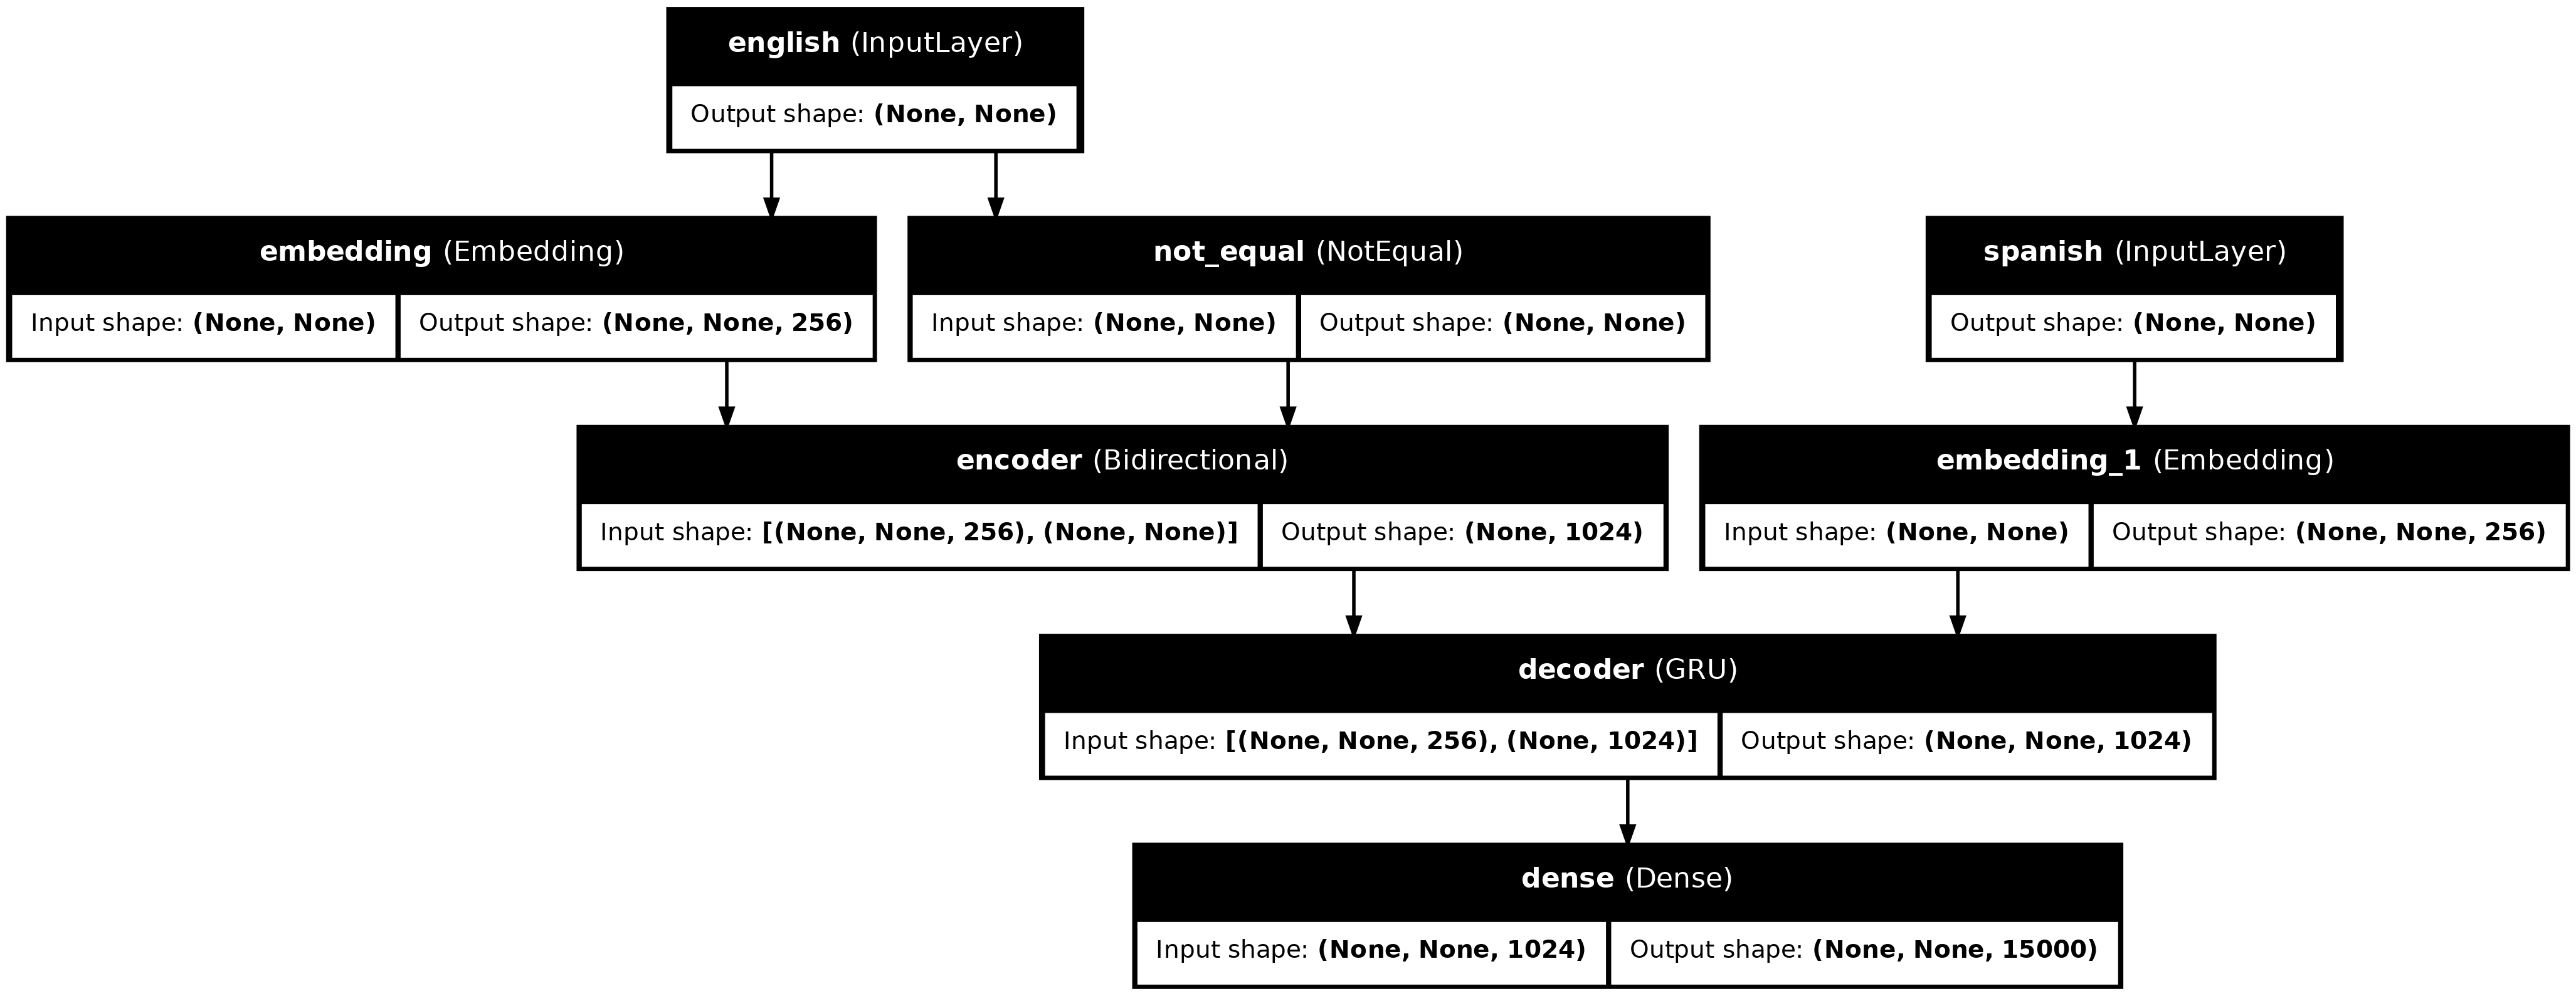

In [17]:
keras.utils.plot_model(seq2seq_rnn, show_shapes=True, show_layer_names=True)

During training the decoder takes the entire target sequence.  But thanks to the step-by-step nature of RNNs, it only looks at 
tokens 0..N in the input to predict token N in the output (which corresponds to the next toekn in the sequence since the
output is offset by one step).

This means we only use information from the past to predict the future, as we should.

Let train it to try it out.

**Note** The following model takes a long time on cpu, I'm getting over 45 minutes per epoch.  GPU cuts this to 2.5 minutes per epoch usually.

In [18]:
seq2seq_rnn.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

history = seq2seq_rnn.fit(train_ds, epochs=20, validation_data=val_ds)

Epoch 1/20


I0000 00:00:1750265200.225183   58485 cuda_dnn.cc:529] Loaded cuDNN version 90300


1302/1302 ━━━━━━━━━━━━━━━━━━━━ 168s 126ms/step - accuracy: 0.1500 - loss: 5.1269 - val_accuracy: 0.1625 - val_loss: 3.6432
Epoch 2/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 162s 124ms/step - accuracy: 0.1744 - loss: 3.4787 - val_accuracy: 0.1995 - val_loss: 2.9133
Epoch 3/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 161s 124ms/step - accuracy: 0.2071 - loss: 2.7728 - val_accuracy: 0.2196 - val_loss: 2.5358
Epoch 4/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 162s 124ms/step - accuracy: 0.2313 - loss: 2.2880 - val_accuracy: 0.2325 - val_loss: 2.3106
Epoch 5/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 158s 121ms/step - accuracy: 0.2526 - loss: 1.9080 - val_accuracy: 0.2407 - val_loss: 2.1857
Epoch 6/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 159s 122ms/step - accuracy: 0.2720 - loss: 1.5929 - val_accuracy: 0.2452 - val_loss: 2.1217
Epoch 7/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 156s 120ms/step - accuracy: 0.2900 - loss: 1.3219 - val_accuracy: 0.2474 - val_loss: 2.0992
Epoch 8/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 158s 121ms/step - accuracy: 0.3

Text(0.5, 0.98, 'GRU Encoder/Decoder Learning Curve Results')

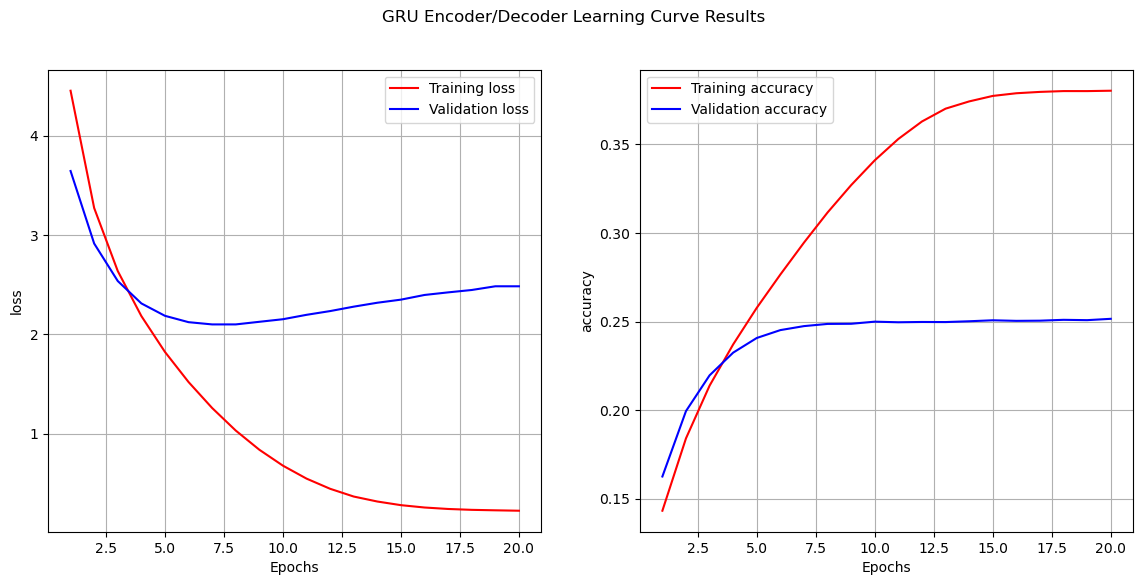

In [21]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')
plt.suptitle('GRU Encoder/Decoder Learning Curve Results')

**TODO**: Didn't get that type of accuracy on the metric, so there may be an issue here.

We picked `accuracy` as a crude way to monitor validation-set performance.  Usually you will get about 64% validation accuracy, which means
that 64% of the time, the top prediction is correct in predicting what the next word in the sentence will be.

In practice, next-token accuracy isn't a great metric for machine translation models.  Because it makes the assumption that the correct target tokens
from 0 to N are already known when predicting token N+1.  In reality during inference, you're generating the target sentence from scratch, and you
can't rely on previously generated tokens being 100% correct.

If you work on a real-world translation system, you will likely use [BLEU](https://medium.com/nlplanet/two-minutes-nlp-learn-the-bleu-metric-by-examples-df015ca73a86) 
(BiLingual Evaluation Understudy) scores to evalute your models, a metric that looks at
entire generated sequences and that seems to correlate well with human perception of translation quality.

At last the model is ready for inference.  We'll pick a few sentences in the test set and check how our model translates them.

We'll start from the seed token "[start]" and feed it into the decoder model, together with the encoded English source
sentence.  We'll retrieve a next-token prediction, and we'll reinject it into the decoder repeatedly, sampling
one new target token at each iteration, until we get to "[end]" or
reach the maximum sentence length.

In [22]:
# we first need the reverse vocabulary dictionary since we will get
# out an index into the target language dictionary
spa_vocab = target_vectorization.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))
max_decoded_sentence_length = 20

def decode_sequence(input_sentence):
    """Use the trained encoder/decoder translator to translate the given
    input sentence in English for us.

    Parameters
    ----------
    input_sentence : str
        A string of the input English sentence to be translated.
    """
    # the source vectorizor will normalize and tokenize sentence for us.
    tokenized_input_sentence = source_vectorization([input_sentence])

    # we will gather the output of the decoder translation in this string, which initially only
    # has the special [start] seed token
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        # basic inference, get prediction of next token from the trained model for the input
        # sentence, and what we have so far in the target translation sentence
        tokenized_target_sentence = target_vectorization([decoded_sentence])
        next_token_predictions = seq2seq_rnn.predict([tokenized_input_sentence, tokenized_target_sentence])

        # convert next token prediction to a string.  argmax gives the token index
        # and use the reverse spanish vocabulary dictionary to look up the word string
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = spa_index_lookup[sampled_token_index]

        # we append the next predicted word to end of translated sentence so for
        decoded_sentence += " " + sampled_token

        # we stop if see special [end] token, or loop will stop once we reach our maximum sentence length
        if sampled_token == "[end]":
            break

    # return the decoded/translated sentence
    return decoded_sentence



Note that the inference setup is rather inefficient.  You can refactor the models and separate them, and have the
decoder run only a single step at each token-sampling iteration.

Here are the results of picking 20 test sentences at random to look at.

In [23]:
# test some sentences
#test_eng_texts = [pair[0] for pair in test_pairs]

# translate 20 randomly selected sentences from the English test inputs
for _ in range(20):
    #input_sentence = random.choice(test_eng_texts)
    input_sentence, target_sentence = random.choice(test_pairs)
    print('-')
    print(input_sentence)
    print(decode_sequence(input_sentence))
    print(target_sentence)

-
He works at the bank.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[start] trabaja trabaja en el banco [end]
[start] Trabaja en el banco. [end]
-
The dog is blind in one eye.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[start] el perro lleva a tom en un [UNK] [end]
[start] El perro es ciego de un ojo. [end]
-
She's very beautiful.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41m

There are many ways the performance of this model could be improved:

- Use a stack of recurrent layers for both the encoder and the decoder.
- Could try LSTM instead of GRU

A few fundamental limitations to using RNN sequence-to-sequence learning:

- The source sequence representation has to be held entirely in the encoder state
  vector(s), which puts significant limitations on the size and complexity of the
  sentences you can translate. It’s a bit as if a human were translating a sentence
  entirely from memory, without looking twice at the source sentence while producing
  the translation.
- RNNs have trouble dealing with very long sequences, since they tend to progressively
  forget about the past—by the time you’ve reached the 100th token in
  either sequence, little information remains about the start of the sequence.
  That means RNN-based models can’t hold onto long-term context, which can
  be essential for translating long documents.

These limitations are what has led the machine learning community to embrace the Transformer architecture,
that can add context and neural attention to a sequence-to-sequence task.

### 11.5.3 Sequence-to-sequence Learning with a Transformer

Sequence-to-sequence learning is the task where a Transformer really shines.

Neural attention enables Transformer models to successfully process sequences that are considerably
longer and more complex than those RNNs can handle.

In a sequence-to-sequence Transformer, the Transformer encoder would naturally play the
role of the encoder, which reads the source sequence and produces an encoded representation
of it. Unlike our previous RNN encoder, though, the Transformer
encoder keeps the encoded representation in a sequence format: it’s a sequence of
context-aware embedding vectors.

The second half of the model is the Transformer decoder.  Crucially,
while doing this, it uses neural attention to identify which tokens in the encoded source
sentence are most closely related to the target token it’s currently trying to predict.

#### The Transformer decoder

Look at the decoder internals: you’ll recognize that it looks very similar to the Transformer encoder, except
that an extra attention block is inserted between the self-attention block applied to
the target sequence and the dense layers of the exit block.

Let's implement it.  We will show a custom subclass again similar to the `TransformerEncoder`

The `call()` method is again almost a straightforward rendering of the connectivity
diagram from the figure of the Transformer Decoder architecture.  But we need to take
into account **causal padding**.

Causal padding is absolutely critical to successfully training
a sequence-to-sequence Transformer. The TransformerDecoder is order-agnostic:
it looks at the entire target sequence at once.  If it were allowed to use its entire
input, it would simply learn to copy input step N+1 to location N in the output.

The fix is simple: we’ll mask the upper half of the pairwise attention matrix to prevent
the model from paying any attention to information from the future—only information
from tokens 0...N in the target sequence should be used when generating
target token N+1.

We’ll add a `get_causal_attention_mask(self, inputs)`
method to our TransformerDecoder to retrieve an attention mask that we can pass to
our MultiHeadAttention layers.

With that function, we can write the full `call()` method implementing the
forward pass of the decoder.

In [14]:
class TransformerDecoder(layers.Layer):
    """Implementaiton of custom TransformerDecoder.  Similar to the encoder, but an extra MutliHeadAttention
    is added to receive the output from the encoder.  Thus in the second MultiHeadAttention we can
    use the target sentence as an attention "query" and source sequence will be both keys and values.
    """
    
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        """Override base constructor to support TransformerDecoder initialization parameters

        Parameters
        ----------
        embed_dim : int
            The size of the embedding dimension, e.g. the size of the input sample token vectors
        dense_dim : int
            The size of the inner dense layer for the Dense projectios of the output of the MultiHead
        num_heads : int
            The number of independent heads (features) in the MultiHeadAttention to use
        """
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads

        # create initial multihead attention layer to get target inputs and
        # compute neural attention on them
        self.attention_1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        # second multihead attention computes attention from encoder source result and
        # the target attention
        self.attention_2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        # same set of dense layers for encoding and projecting back to output embedding dimension
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )

        # an extra normalizaiton is added so there is now one after each multihead attention and before
        # the final output
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()
        # this may answer my previous question, this was not shown in previous encoder model
        self.supports_masking = True

    def get_causal_attention_mask(self, inputs):
        """The TransformerDecoder is order-agnostic, we must take into account
        that it has information about th efuture.  We must implement causal padding.
        Only information from tokens 0..N in the target sequence should be used
        when generating target N+1

        Parameters
        ----------
        inputs : ndarray
        inputs : ndarray (batch_size, sequence_length, embedding_dim)
            The inputs for Keras layers always have some number of samples.  In our example
            we use token sequences where each token is embeded in an embedding space of embedding_dim
            number of dimensions.        
        """
        # infer the batch size and sequence length from inputs
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]

        
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)

        # generate a matrix of shape (sequence_length, sequence_length) with 1's in one half and
        # 0's in the other
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        
        # replicate it along the batch axis to get a matrix of shape
        # (batch_size, sequence_length, sequence_length)
        mult = tf.concat(
            [tf.expand_dims(batch_size, -1),
             tf.constant([1, 1], dtype=tf.int32)], axis=0)
        return tf.tile(mask, mult)

    def call(self, inputs, encoder_outputs, mask=None):
        """Computation goes in call member function.

        Parameters
        ----------
        inputs : ndarray (num_samples, max_tokens, embedding_dim)
            The inputs for Keras layers always have some number of samples.  In our example
            we use token sequences where each token is embeded in an embedding space of embedding_dim
            number of dimensions.
        encoder_outputs : ndarray (num_samples, max_tokens, embedding_dim)?
            We are expecting 2 input paths, this will receive the outputs from the encoder
            to inject into our second multihead attention layer.
        """
        # get the causal mask and combine with the mask into this
        # TransformerEncoder.  causal_mask masks out future events and
        # padding_mask masks out sequences that are short
        causal_mask = self.get_causal_attention_mask(inputs)
        if mask is not None:
            padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype="int32")
            padding_mask = tf.minimum(padding_mask, causal_mask)
        else: # bug in book, need to ensure this is set
            padding_mask = mask

        # first multihead attention, gets target inputs
        attention_output_1 = self.attention_1(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=causal_mask)

        # output of first attention is then normalized, there is a residual
        # connection so we get raw inputs and attention output combined here
        attention_output_1 = self.layernorm_1(inputs + attention_output_1)

        # second multihead attention uses the target outputs for the query
        # and the value and key come from the encoder outputs
        attention_output_2 = self.attention_2(
            query=attention_output_1,
            value=encoder_outputs,
            key=encoder_outputs,
            attention_mask=padding_mask,
        )

        # again normalize output of second attention, and again use a residual
        # connection and combine here
        attention_output_2 = self.layernorm_2(
            attention_output_1 + attention_output_2)

        # the output from combined attention is fed into the dense layer
        proj_output = self.dense_proj(attention_output_2)

        # final normalization before returning result, again a residual
        # connection around the dense layers is combined here
        return self.layernorm_3(attention_output_2 + proj_output)

    def get_config(self):
        """Implement serialization so that we can save the model. Should return a
        python dict that contains values of the constructor arguments used to create the
        layer.  So we chain the super class get_config, then add in our 3 additional
        constructor arguments.
        """
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config

#### Putting it all together: A transformer for machine translation

The end-to-end Transformer is the model we'll be training.  It maps the source sequence and the target sequence
to the target sequence one step in the future.

It combines pieces you have seen before: `PositionalEmbedding` layers and the `TransformerEncoder` and our new
`TransformerDecoder` variant.  Note that both the encoder and decoder are shape-invariant, so you could be
stacking many of them to create a more powerful encoder or decoder.



In [15]:
# create end-to-end Transformer translator
embed_dim = 256
dense_dim = 2048
num_heads = 8

# encode the source sentences using the previous custom PositionalEmbedding
# and TransformerEncoder layers
encoder_inputs = keras.Input(shape=(None,), dtype="int64", name="english")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(encoder_inputs)
# encode the source sentence
encoder_outputs = TransformerEncoder(embed_dim, dense_dim, num_heads, name="encoder")(x)

# create the decoder part.  Again we need a PositionalEncoder before the
# TransformerDecoder here
decoder_inputs = keras.Input(shape=(None,), dtype="int64", name="spanish")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(decoder_inputs)
# encode the target sentence and combine it with encoded source sentence, notice
# we get the inputs from the spanish source, and the encoder outputs here
x = TransformerDecoder(embed_dim, dense_dim, num_heads, name="decoder")(x, encoder_outputs)
#x = layers.Dropout(0.5)(x)
decoder_outputs = layers.Dense(vocab_size, activation="softmax")(x)

transformer = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

In [16]:
# lets look at the model summary and network graph
transformer.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spanish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ english[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ my_tf_not_equal_la… │ (None, None)      │          0 │ english[0][0]     │
│ (MyTfNotEqualLayer) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ spanish[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, None, 256) │  3,155,456 │ positional_embed… │
│ (TransformerEncode… │                   │            │ my_tf_not_equal_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, None, 256) │  5,259,520 │ positional_embed… │
│ (TransformerDecode… │                   │            │ encoder[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, None,      │  3,855,000 │ decoder[0][0]     │
│                     │ 15000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,960,216 (76.14 MB)

 Trainable params: 19,960,216 (76.14 MB)

 Non-trainable params: 0 (0.00 B)

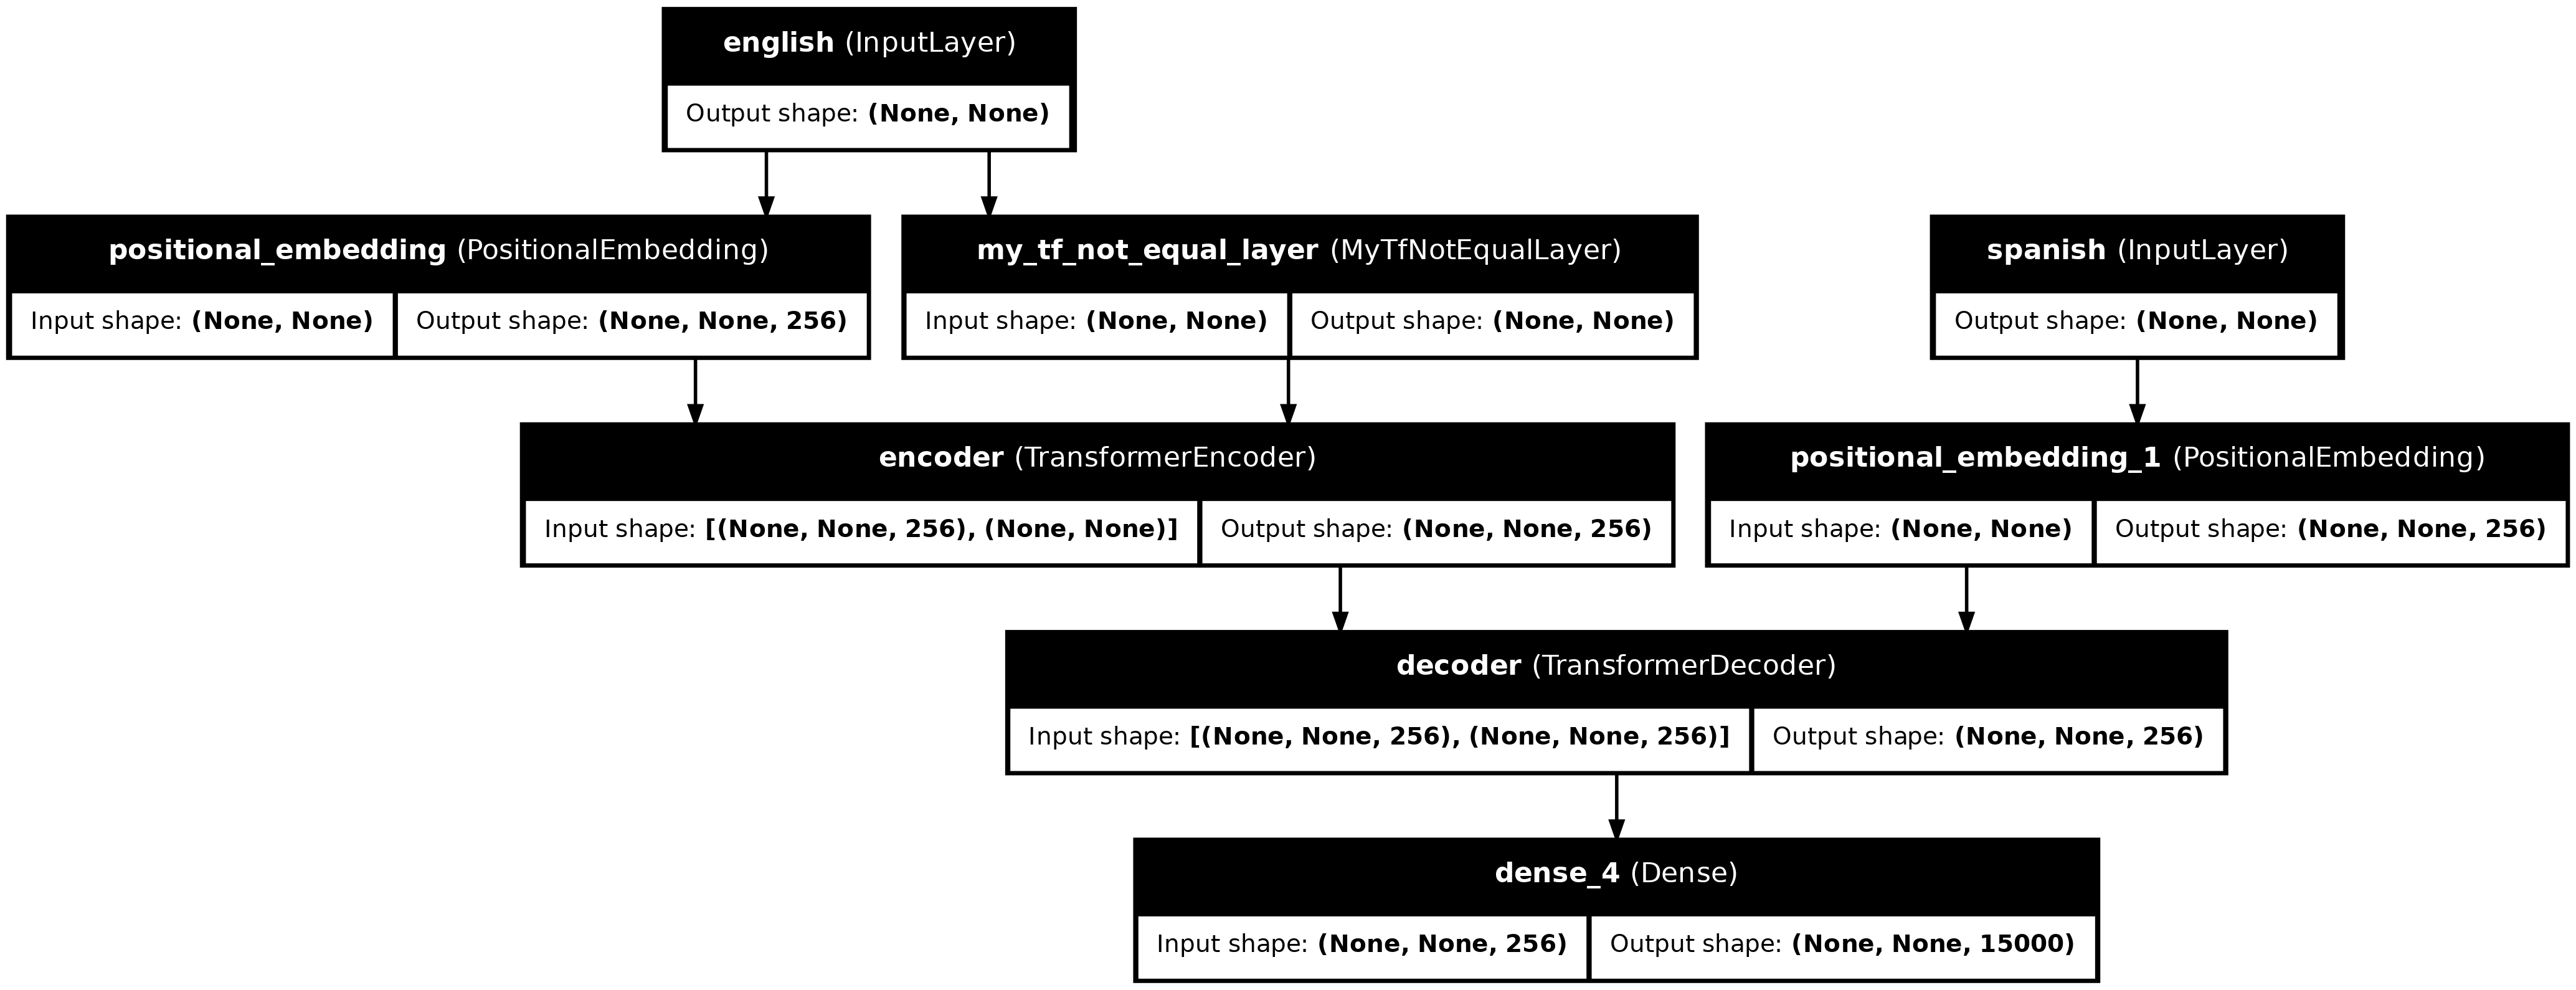

In [17]:
keras.utils.plot_model(transformer, show_shapes=True, show_layer_names=True)

We're now ready to train our model.

In [ ]:
transformer.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

history = transformer.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50


I0000 00:00:1750275184.641854    1368 service.cc:152] XLA service 0x74b33800b360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750275184.641895    1368 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-06-18 19:33:04.815878: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-06-18 19:33:04.930180: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1750275185.797522    1368 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-18 19:33:07.154215: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_14', 820 bytes spill stores,

 885/1302 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.1521 - loss: 4.5438

2025-06-18 19:34:00.369049: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-06-18 19:34:02.238512: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_78', 540 bytes spill stores, 416 bytes spill loads

2025-06-18 19:34:02.341147: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_78', 432 bytes spill stores, 344 bytes spill loads

2025-06-18 19:34:02.619894: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_78', 428 bytes spill stores, 340 bytes spill loads

2025-06-18 19:34:03.423131: I external/local_xla/xla/stream_exe

1301/1302 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1663 - loss: 4.1745

2025-06-18 19:34:37.271942: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-06-18 19:34:41.303681: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-06-18 19:34:42.432014: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24', 428 bytes spill stores, 340 bytes spill loads

2025-06-18 19:34:42.670108: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_24', 108 bytes spill stores, 116 bytes spill loads

2025-06-18 19:34:42.949785: I external/local_xla/xla/stream_executor/cuda/subprocess_c

1302/1302 ━━━━━━━━━━━━━━━━━━━━ 108s 67ms/step - accuracy: 0.1663 - loss: 4.1730 - val_accuracy: 0.2549 - val_loss: 2.1494
Epoch 2/50
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 60s 46ms/step - accuracy: 0.2622 - loss: 2.0265 - val_accuracy: 0.2732 - val_loss: 1.7724
Epoch 3/50
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 59s 45ms/step - accuracy: 0.2849 - loss: 1.5673 - val_accuracy: 0.2766 - val_loss: 1.7177
Epoch 4/50
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 59s 45ms/step - accuracy: 0.2989 - loss: 1.3131 - val_accuracy: 0.2802 - val_loss: 1.6813
Epoch 5/50
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 59s 45ms/step - accuracy: 0.3095 - loss: 1.1385 - val_accuracy: 0.2795 - val_loss: 1.7316
Epoch 6/50
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 59s 45ms/step - accuracy: 0.3177 - loss: 1.0079 - val_accuracy: 0.2804 - val_loss: 1.7709
Epoch 7/50
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 59s 45ms/step - accuracy: 0.3244 - loss: 0.9053 - val_accuracy: 0.2784 - val_loss: 1.8266
Epoch 8/50
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 60s 46ms/step - accuracy: 0.3303 - loss: 0.8

In [ ]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')
plt.suptitle('GRU Encoder/Decoder Learning Curve Results')

Finally let's try using our model to translate never seen before English sentences from the test
set again.  The setup is identitical to what we did before, but we need to use the transformer model.

In [ ]:
spa_vocab = target_vectorization.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))
max_decoded_sentence_length = 20


def decode_sequence(input_sentence):
    """Use the trained encoder/decoder translator to translate the given
    input sentence in English for us.

    Parameters
    ----------
    input_sentence : str
        A string of the input English sentence to be translated.
    """
    # the source vectorizor will normalize and tokenize sentence for us.
    tokenized_input_sentence = source_vectorization([input_sentence])

    # we will gather the output of the decoder translation in this string, which initially only
    # has the special [start] seed token
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        # basic inference, get prediction of next token from the trained model for the input
        # sentence, and what we have so far in the target translation sentence
        tokenized_target_sentence = target_vectorization([decoded_sentence])
        next_token_predictions = transformer.predict([tokenized_input_sentence, tokenized_target_sentence])

        # convert next token prediction to a string.  argmax gives the token index
        # and use the reverse spanish vocabulary dictionary to look up the word string
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = spa_index_lookup[sampled_token_index]

        # we append the next predicted word to end of translated sentence so for
        decoded_sentence += " " + sampled_token

        # we stop if see special [end] token, or loop will stop once we reach our maximum sentence length
        if sampled_token == "[end]":
            break

    # return the decoded/translated sentence
    return decoded_sentence

In [ ]:
# test some sentences
#test_eng_texts = [pair[0] for pair in test_pairs]

# translate 20 randomly selected sentences from the English test inputs
for _ in range(20):
    #input_sentence = random.choice(test_eng_texts)
    input_sentence, target_sentence = random.choice(test_pairs)
    print('-')
    print(input_sentence)
    print(decode_sequence(input_sentence))
    print(target_sentence)

**Note**: Wasn't remarked upon, but the transformer was trained for twice as many epochs as the GRU sequence-to-sequence model.  In my run, the

**TODO**: Also this model is not getting same performance discussed in text.  Will need to debug.

Subjectively the transformer seems to perform significantly better than the
GRU based translation model.  

## Summary

<font color='blue'>
    
- A sequence-to-sequence model takes a sequence as input and translates it into a different sequence.
- An *encoder* model turns the source sequence into an intermediate representation.
- A *decoder* takes the encoder output and is trained to predict the next token by looking at both all previous tokens,
  and the encoded source sequence.
- The TransformerDecoder is similar to the TransformerEncoder, but has an additional attention layer that receives the encoded output
  from an encoder.
